## <span style = 'color:orange; font-family:JetBrains Mono'>MiniBatch Gradient Descent</span>
> on STUDENTS.csv

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import time

In [60]:
# Loading data
df = pd.read_csv('STUDENTS.csv')
df.head()

,study_hrs,prev_score,sleep_hrs,ques_paper,perf_index
0,7,99,9,1,91.0
1,4,82,4,2,65.0
2,8,51,7,2,45.0
3,5,52,5,2,36.0
4,7,75,8,5,66.0


In [61]:
# features and target
x = df.iloc[:, 0:4]
y = df.iloc[:, -1]

In [62]:
# normalizing
x = (x - x.mean()) / x.std()
y = (y - y.mean()) / y.std()

In [63]:
# sklearn for comparison
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

In [64]:
# data split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=2)

In [65]:
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred_sk = lr.predict(x_test)

In [66]:
# sklearn evaluation and parameters
r2_sk = r2_score(y_test, y_pred_sk)
print('R2 Score:',r2_sk)
print('Intercept:',lr.intercept_)
print('Coefficient:',lr.coef_)

R2 Score: 0.9887873065706716
Intercept: 0.00034171958509645033
Coefficient: [0.38457423 0.92049294 0.04225189 0.02969702]


In [67]:
df[['study_hrs','prev_score','sleep_hrs','ques_paper','perf_index']].corr()

,study_hrs,prev_score,sleep_hrs,ques_paper,perf_index
study_hrs,1.000000,-0.012390,0.001245,0.017463,0.373730
prev_score,-0.012390,1.000000,0.005944,0.007888,0.915189
sleep_hrs,0.001245,0.005944,1.000000,0.003990,0.048106
ques_paper,0.017463,0.007888,0.003990,1.000000,0.043268
perf_index,0.373730,0.915189,0.048106,0.043268,1.000000


In [68]:
# custom class mini batch
class mini_batch:
    def __init__(self, learning_rate, epochs, batch_size):
        self.epochs = epochs
        self.n = learning_rate
        self.batch_size = batch_size
        self.loss_list = []
        self.coef_ = None
        self.intercept_ = None
        
    
    def fit(self, x_train, y_train):
        x_train = x_train.values
        y_train = y_train.values
        
        self.intercept_ = 0
        self.coef_ = np.ones(x_train.shape[1])

        for i in range(self.epochs):
            for j in range(int(x_train.shape[0] / self.batch_size)): # number of batches
                idx = random.sample(range(x_train.shape[0]), self.batch_size) # batch elements

                y_pred = self.intercept_ + np.dot(x_train[idx], self.coef_)

                # update intercept
                grad_intercept = (-2/self.batch_size) * np.sum(y_train[idx] - y_pred)
                self.intercept_ -= (self.n * grad_intercept)

                # update coef
                grad_coef = (-2/self.batch_size) * np.dot((y_train[idx] - y_pred), x_train[idx])
                self.coef_ -= (self.n * grad_coef)

            prediction = self.intercept_ + np.dot(x_train, self.coef_)
            loss = np.mean((y_train - prediction)**2)
            self.loss_list.append(loss)
            print(f'step {i} | loss = {loss}')
        print('final parameters...')
        print('Intercept:',self.intercept_)
        print('Coefficient:',self.coef_)
    
    def predict(self, x_test):
        return self.intercept_ + np.dot(x_test, self.coef_)

In [69]:
gd = mini_batch(0.01, 1000, 1000)
start = time.time()
gd.fit(x_train, y_train)
print('--------------------------------------------')
print('Training time =', time.time() - start)

step 0 | loss = 1.6474564908809326
step 1 | loss = 1.1957834378815781
step 2 | loss = 0.8613014936885466
step 3 | loss = 0.6266461048906824
step 4 | loss = 0.45674469402403556
step 5 | loss = 0.3335639239431123
step 6 | loss = 0.24262012633637017
step 7 | loss = 0.1777828822090972
step 8 | loss = 0.13084341325331836
step 9 | loss = 0.09702906408398217
step 10 | loss = 0.07270797682411224
step 11 | loss = 0.05563483540448001
step 12 | loss = 0.04331952361623619
step 13 | loss = 0.034612581388864624
step 14 | loss = 0.028136072740828365
step 15 | loss = 0.02348210888381299
step 16 | loss = 0.020179460274651128
step 17 | loss = 0.01772737234533066
step 18 | loss = 0.01600984971339914
step 19 | loss = 0.014776836311491024
step 20 | loss = 0.01390854981949051
step 21 | loss = 0.01324372878246764
step 22 | loss = 0.012767530014370414
step 23 | loss = 0.012408168427222819
step 24 | loss = 0.012174713558504224
step 25 | loss = 0.012013145884365105
step 26 | loss = 0.011877067381359538
step 27 

In [70]:
y_pred_cc = gd.predict(x_test)
r2_cc = r2_score(y_test, y_pred_cc)
r2_cc

0.9887885372105788

In [83]:
gd2 = mini_batch(0.1, 500, 1000)
start = time.time()
gd2.fit(x_train, y_train)
print('--------------------------------------------')
print('Training time =', time.time() - start)

step 0 | loss = 0.07076612756072946
step 1 | loss = 0.01325611278951583
step 2 | loss = 0.011583389995252396
step 3 | loss = 0.011550528740973178
step 4 | loss = 0.011546825281574516
step 5 | loss = 0.011549727942178694
step 6 | loss = 0.011547279847854289
step 7 | loss = 0.011548495741437091
step 8 | loss = 0.011546590348364246
step 9 | loss = 0.011551334020232219
step 10 | loss = 0.01154848979457364
step 11 | loss = 0.011550296471982708
step 12 | loss = 0.011545990576201778
step 13 | loss = 0.011548297268738463
step 14 | loss = 0.011548602599407886
step 15 | loss = 0.01154979864928822
step 16 | loss = 0.011545035782925695
step 17 | loss = 0.01154545199239603
step 18 | loss = 0.011544127749631247
step 19 | loss = 0.01154617894637032
step 20 | loss = 0.011546393597724353
step 21 | loss = 0.011545859866719509
step 22 | loss = 0.01154704928588277
step 23 | loss = 0.01155231956645195
step 24 | loss = 0.011545001307247555
step 25 | loss = 0.011545911767535236
step 26 | loss = 0.01155534796

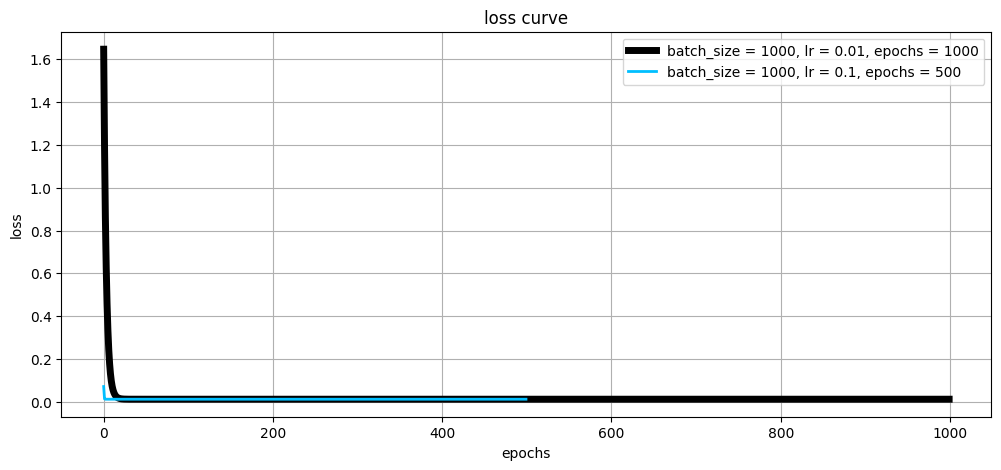

In [86]:
# loss curve
# (learning_rate, epochs, batch_size)
plt.figure(figsize=(12,5))
plt.plot(range(gd.epochs), gd.loss_list, color = 'k', lw = 5, label = 'batch_size = 1000, lr = 0.01, epochs = 1000')
plt.plot(range(gd2.epochs), gd2.loss_list, color = 'deepskyblue', lw = 2, label = 'batch_size = 1000, lr = 0.1, epochs = 500')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('loss curve')
plt.grid(True)
plt.legend()
plt.show()